In [ ]:
''' Problem Statement:
# The objective is to build a machine learning model to predict the genre of TV shows and movies using metadata such as title, description, cast, etc.
# This is a multi-label classification problem where each title can belong to multiple genres.
focus:
- Build an end-to-end ML pipeline
- Compare models
- Explain predictions using interpretability techniques
'''

In [ ]:

# Import necessary libraries
import argparse
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
 
warnings.filterwarnings("ignore")

In [4]:
# load dataset
df=pd.read_csv("tv-shows.csv")

In [6]:
df.head()

,id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform
0,1,Movie,ChuChuTV Surprise Eggs Learning Videos (English),NaN,NaN,NaN,"October 18, 2019",2019,TV-Y,61 min,Children & Family Movies,From colors and letters to animals of all kind...,Netflix
1,2,Movie,The Journey Is the Destination,Bronwen Hughes,"Ben Schnetzer, Kelly Macdonald, Sam Hazeldine,...",United States,"November 7, 2017",2016,R,123 min,Dramas,Spirited 22-year-old activist and photojournal...,Netflix
2,3,TV Show,Champions,NaN,"Anders Holm, Fortune Feimster, Andy Favreau, J...",United States,"June 19, 2021",2018,TV-14,1 Season,TV Comedies,"Years after getting his girlfriend pregnant, w...",Netflix
3,4,TV Show,The Returned,NaN,"Anne Cosigny, Frédéric Pierrot, Clotilde Hesme...",France,"February 17, 2019",2015,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Horror",On returning home and finding they're believed...,Netflix
4,5,Movie,Super Bheem Bana Vajraveer,Sumit Das,"Sonal Kaushal, Rupa Bhimani, Julie Tejwani, Sa...",India,"June 18, 2019",2018,TV-Y7,63 min,Children & Family Movies,"Hoping to find a magical root, a monster has c...",Netflix


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9338 entries, 0 to 9337
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            9338 non-null   int64 
 1   type          9338 non-null   object
 2   title         9338 non-null   object
 3   director      6483 non-null   object
 4   cast          8400 non-null   object
 5   country       8376 non-null   object
 6   date_added    9325 non-null   object
 7   release_year  9338 non-null   int64 
 8   rating        9331 non-null   object
 9   duration      9335 non-null   object
 10  listed_in     9338 non-null   object
 11  description   9338 non-null   object
 12  platform      9338 non-null   object
dtypes: int64(2), object(11)
memory usage: 948.5+ KB


In [8]:
# SUMMARY OF DATASET

def print_summary(df: pd.DataFrame) -> None:
    print("\n=== DATASET OVERVIEW ===")
    print(df.dtypes.to_string())
    print("\n=== MISSING VALUES ===")
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    summary = pd.DataFrame({"missing": missing, "pct": pct})
    print(summary[summary["missing"] > 0].to_string())

In [9]:
print_summary(df)


=== DATASET OVERVIEW ===
id               int64
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
platform        object

=== MISSING VALUES ===
            missing    pct
director       2855  30.57
cast            938  10.04
country         962  10.30
date_added       13   0.14
rating            7   0.07
duration          3   0.03


In [12]:
#  Plot 1 – Missing value heatmap
def plot_missing(df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_pct = df.isnull().mean() * 100
    missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
    bars = ax.barh(missing_pct.index, missing_pct.values, color = "#4C72B0")
    ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Values by Column")
    ax.set_xlim(0, missing_pct.max() * 1.15)
    fig.tight_layout()
    print(fig)

Figure(1000x400)


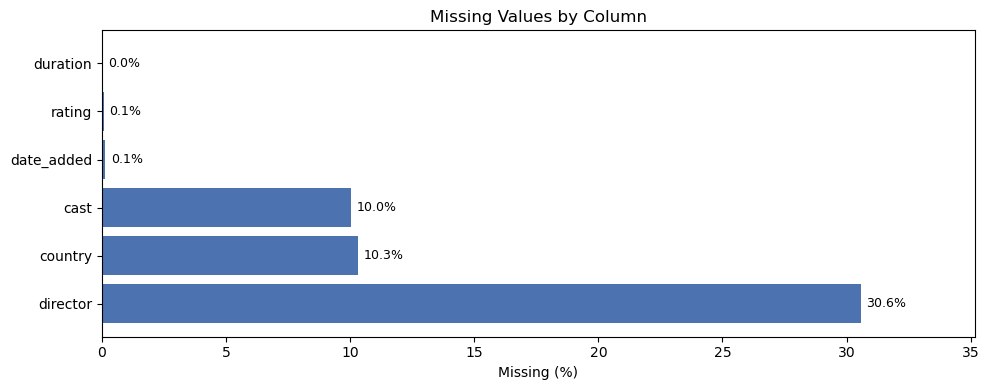

In [13]:
plot_missing(df)

In [15]:

# Key observations: 'director' has the highest missing rate (~30%), followed by 'country' (~10%), 'cast' (~10%), 'date_added' (~0.1%), 'rating' (~0.07%), and 'duration' (~0.03%).

In [17]:
# Plot 2 – Type distribution

def plot_type_dist(df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(6, 4))
    counts = df["type"].value_counts()
    bars = ax.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452"], width=0.5)
    ax.bar_label(bars, fmt="%d", padding=4)
    ax.set_title("Movie vs TV Show Distribution")
    ax.set_ylabel("Count")
    fig.tight_layout()
    print(fig)

Figure(600x400)


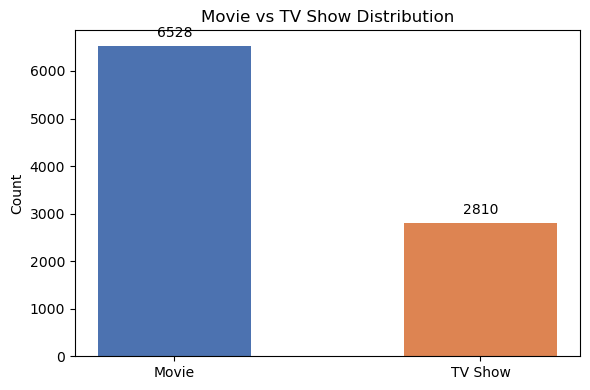

In [18]:
plot_type_dist(df)

In [19]:
# Key observation: The dataset has a higher proportion of movies compared to TV shows, indicating a focus on film content.

In [20]:
# Plot 3 – Individual genre frequency (top N)
def plot_genre_freq(df: pd.DataFrame, top_n: int = 20) -> None:
    genre_series = df["listed_in"].str.split(", ").explode()
    counts = genre_series.value_counts().head(top_n)
 
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(counts.index[::-1], counts.values[::-1], color="#4C72B0")
    ax.bar_label(bars, fmt="%d", padding=4, fontsize=8)
    ax.set_xlabel("Frequency")
    ax.set_title(f"Top {top_n} Individual Genre Labels")
    fig.tight_layout()
    print(fig)
 
    return genre_series

Figure(1000x600)


0       Children & Family Movies
1                         Dramas
2                    TV Comedies
3         International TV Shows
3                      TV Dramas
                  ...           
9336                      Comedy
9336               Coming of Age
9337            Action-Adventure
9337            Animals & Nature
9337                   Animation
Name: listed_in, Length: 21212, dtype: object

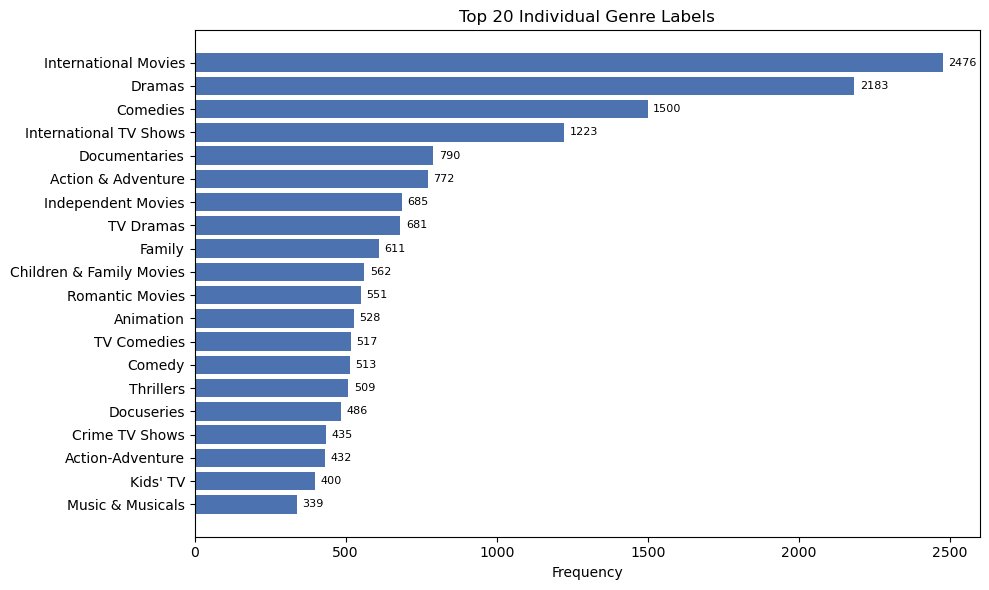

In [21]:
plot_genre_freq(df)

In [22]:
# Plot 4 – Labels-per-row distribution

def plot_label_count_dist(df: pd.DataFrame) -> None:
    label_counts = df["listed_in"].str.split(", ").apply(len)
    fig, ax = plt.subplots(figsize=(6, 4))
    label_counts.value_counts().sort_index().plot(
        kind="bar", ax=ax, color="#4C72B0", rot=0
    )
    ax.set_xlabel("Number of genre labels per title")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of Genre Labels per Title")
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())), (p.get_x() + 0.1, p.get_height() + 20))
    fig.tight_layout()
    print(fig)

Figure(600x400)


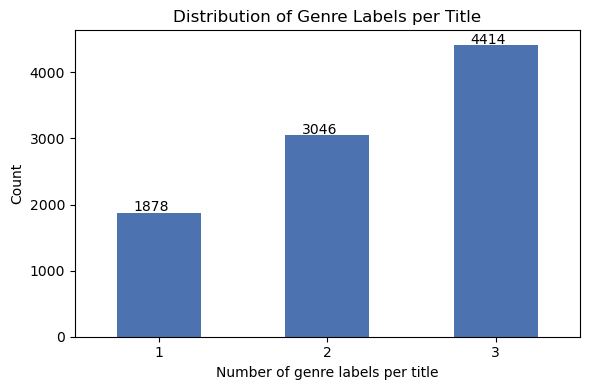

In [23]:
plot_label_count_dist(df)

In [24]:
# Plot 5 – Genre co-occurrence heatmap (top 15)

def plot_cooccurrence(df: pd.DataFrame, top_n: int = 15) -> None:
    genre_lists = df["listed_in"].str.split(", ")
    mlb = MultiLabelBinarizer()
    genre_matrix = pd.DataFrame(
        mlb.fit_transform(genre_lists), columns=mlb.classes_, index=df.index
    )
    # keep top-N genres by frequency
    top_genres = genre_matrix.sum().nlargest(top_n).index
    sub = genre_matrix[top_genres]
    cooc = sub.T.dot(sub)
 
    fig, ax = plt.subplots(figsize=(11, 9))
    mask = np.eye(len(top_genres), dtype=bool)
    sns.heatmap(
        cooc,
        mask=mask,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=0.5,
        ax=ax,
        annot_kws={"size": 7},
    )
    ax.set_title(f"Genre Co-occurrence Matrix (Top {top_n})")
    fig.tight_layout()
    print(fig)

Figure(1100x900)


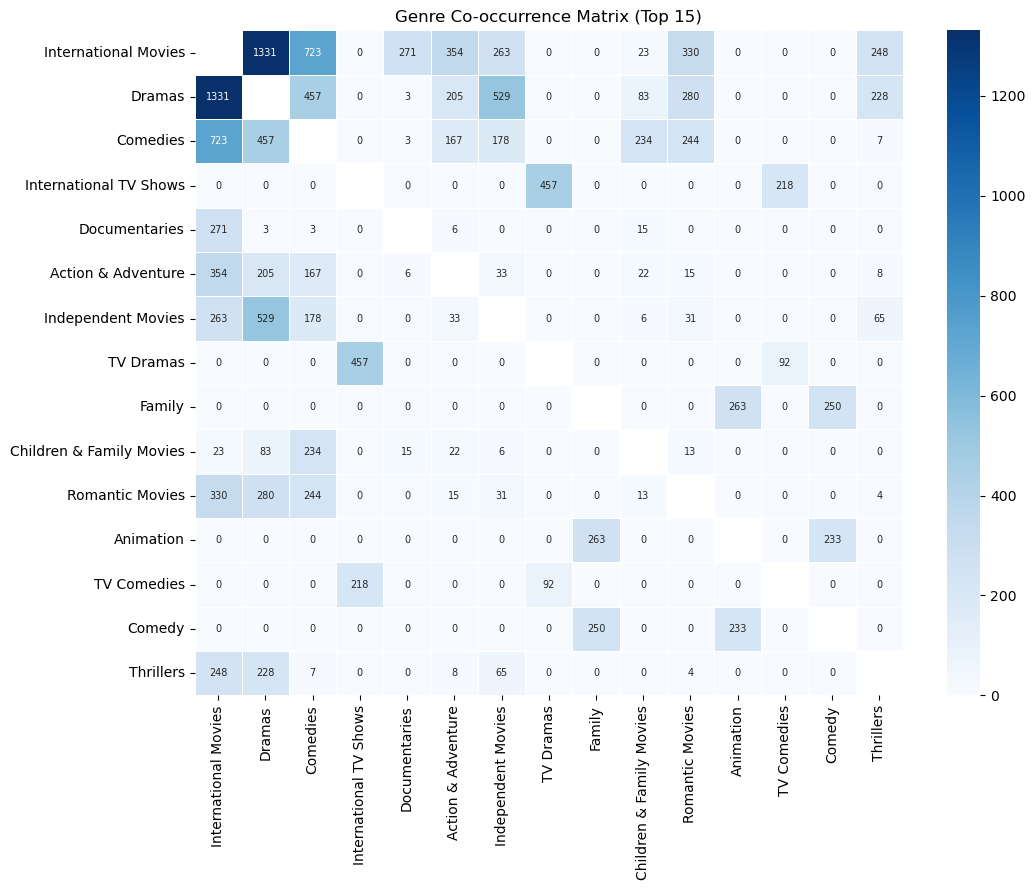

In [25]:
plot_cooccurrence(df)

In [26]:
# Insight:
# Drama appears to be the most dominant genre.
# Some genres frequently appear together (e.g., Drama + Romance)

In [27]:
# Plot 6 – Release year histogram
def plot_release_year(df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(10, 4))
    df["release_year"].hist(bins=40, ax=ax, color="#4C72B0", edgecolor="white")
    ax.set_xlabel("Release Year")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of Release Year")
    fig.tight_layout()
    print(fig)

Figure(1000x400)


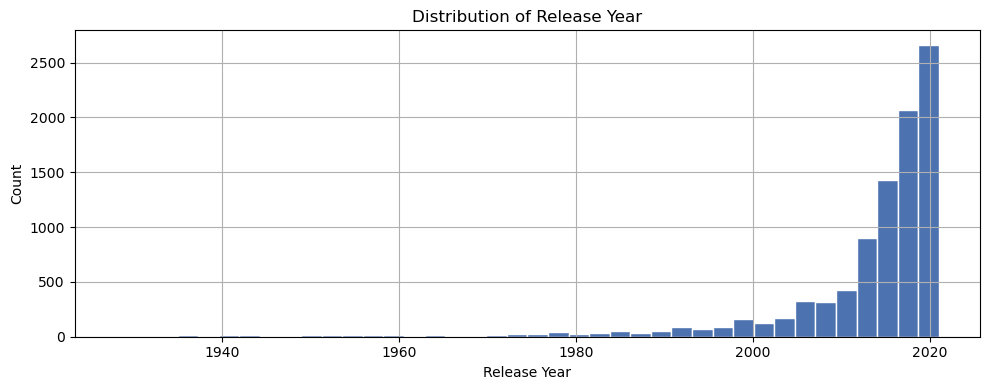

In [28]:
plot_release_year(df)

In [31]:
# Plot 7 – Rating distribution

def plot_rating(df: pd.DataFrame) -> None:
    # exclude the 3 rows with duration leaked into rating
    clean = df[~df["rating"].str.contains("min", na=False)]
    counts = clean["rating"].value_counts()
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(counts.index, counts.values, color="#4C72B0")
    ax.bar_label(bars, fmt="%d", padding=2, fontsize=8)
    ax.set_xlabel("Rating")
    ax.set_ylabel("Count")
    ax.set_title("Content Rating Distribution")
    fig.tight_layout()
    print(fig)

Figure(1000x400)


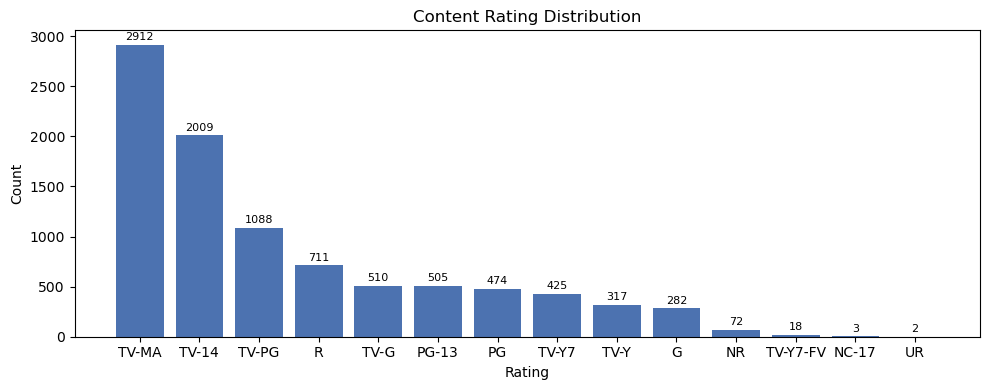

In [32]:
plot_rating(df)

In [33]:
# Plot 8 – Movie runtime distribution

def plot_duration(df: pd.DataFrame) -> None:
    movies = df[df["type"] == "Movie"].copy()
    movies["duration_min"] = (
        movies["duration"].str.extract(r"(\d+)").astype(float)
    )
    fig, ax = plt.subplots(figsize=(10, 4))
    movies["duration_min"].dropna().hist(bins=40, ax=ax, color="#4C72B0", edgecolor="white")
    ax.set_xlabel("Duration (minutes)")
    ax.set_ylabel("Count")
    ax.set_title("Movie Runtime Distribution")
    fig.tight_layout()
    print(fig)

Figure(1000x400)


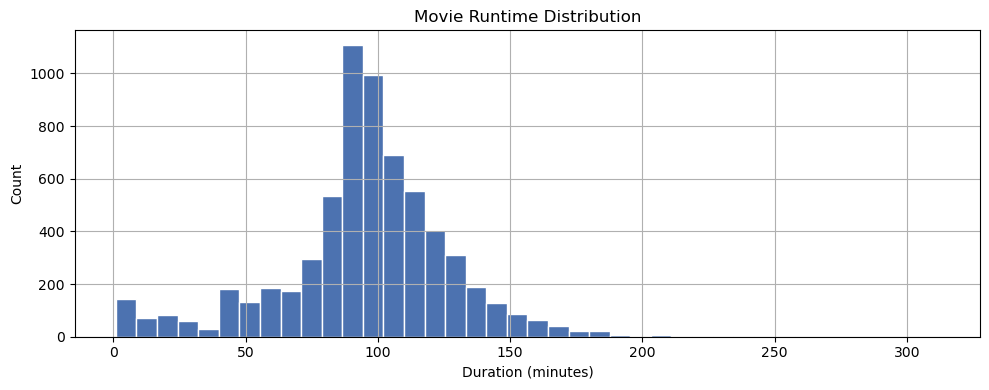

In [34]:
plot_duration(df)

In [35]:
# Plot 9 – TV show seasons distribution

def plot_seasons(df: pd.DataFrame) -> None:
    shows = df[df["type"] == "TV Show"].copy()
    shows["seasons"] = shows["duration"].str.extract(r"(\d+)").astype(float)
    counts = shows["seasons"].value_counts().sort_index().head(10)
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(counts.index.astype(int), counts.values, color="#4C72B0", width=0.6)
    ax.bar_label(bars, fmt="%d", padding=3)
    ax.set_xlabel("Number of Seasons")
    ax.set_ylabel("Count")
    ax.set_title("TV Show — Number of Seasons Distribution")
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    fig.tight_layout()
    print(fig)

Figure(800x400)


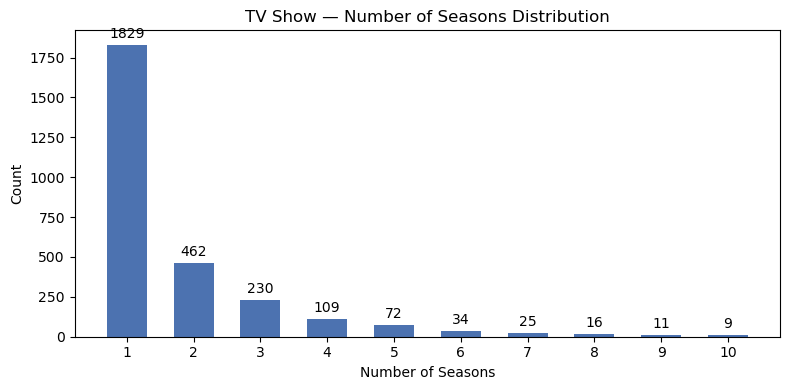

In [36]:
plot_seasons(df)

In [37]:
# Plot 10 – Description length

def plot_desc_length(df: pd.DataFrame) -> None:
    df = df.copy()
    df["desc_len"] = df["description"].str.len()
    fig, ax = plt.subplots(figsize=(10, 4))
    df["desc_len"].hist(bins=50, ax=ax, color="#4C72B0", edgecolor="white")
    ax.set_xlabel("Description Length (characters)")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of Description Lengths")
    ax.axvline(df["desc_len"].mean(), color="red", linestyle="--", label=f"Mean: {df['desc_len'].mean():.0f}")
    ax.legend()
    fig.tight_layout()
    print(fig)

Figure(1000x400)


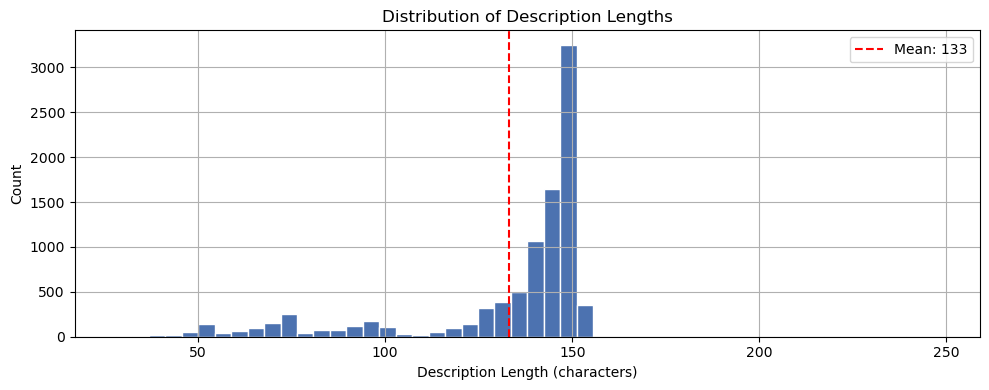

In [38]:
plot_desc_length(df)

In [39]:
# Plot 11 – Top 15 countries

def plot_country(df: pd.DataFrame) -> None:
    # take only primary country (first listed)
    primary_country = df["country"].str.split(", ").str[0]
    counts = primary_country.value_counts().head(15)
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(counts.index[::-1], counts.values[::-1], color="#4C72B0")
    ax.bar_label(bars, fmt="%d", padding=4, fontsize=9)
    ax.set_xlabel("Count")
    ax.set_title("Top 15 Countries (Primary Country)")
    fig.tight_layout()
    print(fig)

Figure(1000x500)


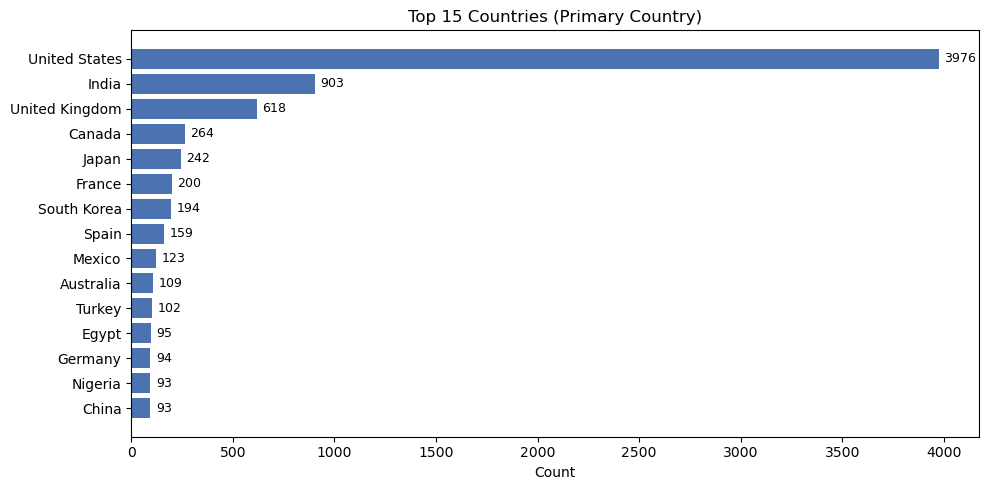

In [40]:
plot_country(df)

In [41]:
# Plot 12 – Platform breakdown

def plot_platform(df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(6, 4))
    counts = df["platform"].value_counts()
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=counts.index,
        autopct="%1.1f%%",
        colors=["#4C72B0", "#DD8452"],
        startangle=140,
    )
    ax.set_title("Platform Distribution")
    fig.tight_layout()
    print(fig)

Figure(600x400)


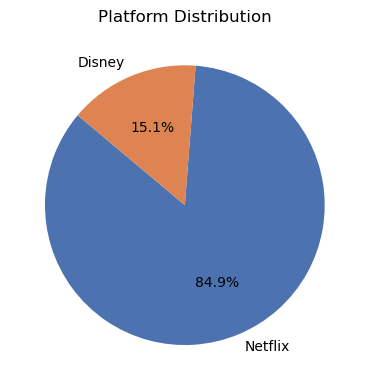

In [42]:
plot_platform(df)

### Data preprocessing & feature engineering for genre prediction

In [44]:
MIN_GENRE_FREQUENCY = 100
RANDOM_STATE = 42
TEST_SIZE = 0.2

In [47]:
RATING_MAP = {
    "G": "kids",
    "TV-Y": "kids",
    "TV-Y7": "kids",
    "TV-Y7-FV": "kids",
    "TV-G": "kids",
    "PG": "family",
    "TV-PG": "family",
    "PG-13": "teen",
    "TV-14": "teen",
    "TV-MA": "adult",
    "R": "adult",
    "NC-17": "adult",
    "NR": "unknown",
    "UR": "unknown",
}

In [51]:
def fix_data_quality(df):
    df = df.copy()

    bad_mask = df["rating"].str.contains("min", na=False)
    df.loc[bad_mask, "duration"] = df.loc[bad_mask, "rating"]
    df.loc[bad_mask, "rating"] = None

    return df

# Some rows have duration wrongly stored in rating (like "66 min")
# Move those values back to duration and clear the rating column
# This fixes incorrect column mix-up in the dataset

In [52]:
df=fix_data_quality(df)
df

,id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform
0,1,Movie,ChuChuTV Surprise Eggs Learning Videos (English),NaN,NaN,NaN,"October 18, 2019",2019,TV-Y,61 min,Children & Family Movies,From colors and letters to animals of all kind...,Netflix
1,2,Movie,The Journey Is the Destination,Bronwen Hughes,"Ben Schnetzer, Kelly Macdonald, Sam Hazeldine,...",United States,"November 7, 2017",2016,R,123 min,Dramas,Spirited 22-year-old activist and photojournal...,Netflix
2,3,TV Show,Champions,NaN,"Anders Holm, Fortune Feimster, Andy Favreau, J...",United States,"June 19, 2021",2018,TV-14,1 Season,TV Comedies,"Years after getting his girlfriend pregnant, w...",Netflix
3,4,TV Show,The Returned,NaN,"Anne Cosigny, Frédéric Pierrot, Clotilde Hesme...",France,"February 17, 2019",2015,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Horror",On returning home and finding they're believed...,Netflix
4,5,Movie,Super Bheem Bana Vajraveer,Sumit Das,"Sonal Kaushal, Rupa Bhimani, Julie Tejwani, Sa...",India,"June 18, 2019",2018,TV-Y7,63 min,Children & Family Movies,"Hoping to find a magical root, a monster has c...",Netflix
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9333,9334,Movie,X-Men Origins: Wolverine,Gavin Hood,"Hugh Jackman, Liev Schreiber, Danny Huston, wi...","United States, United Kingdom","June 4, 2021",2009,PG-13,108 min,"Action-Adventure, Family, Science Fiction",Wolverine unites with legendary X-Men to fight...,Disney
9334,9335,Movie,Night at the Museum: Battle of the Smithsonian,Shawn Levy,"Ben Stiller, Amy Adams, Owen Wilson, Hank Azar...","United States, Canada","April 2, 2021",2009,PG,106 min,"Action-Adventure, Comedy, Family",Larry Daley returns to rescue some old friends...,Disney
9335,9336,Movie,Eddie the Eagle,Dexter Fletcher,"Tom Costello, Jo Hartley, Keith Allen, Dickon ...","United Kingdom, Germany, United States","December 18, 2020",2016,PG-13,107 min,"Biographical, Comedy, Drama","True story of Eddie Edwards, a British ski-jum...",Disney
9336,9337,Movie,Bend It Like Beckham,Gurinder Chadha,"Parminder Nagra, Keira Knightley, Jonathan Rhy...","United Kingdom, Germany, United States","September 18, 2020",2003,PG-13,112 min,"Buddy, Comedy, Coming of Age",Despite the wishes of their traditional famili...,Disney


In [56]:
# Step 2 – Parse numeric features

def parse_numeric_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
 
    # Movie runtime in minutes
    movie_mask = df["type"] == "Movie"
    df["duration_numeric"] = np.nan
    df.loc[movie_mask, "duration_numeric"] = (
        df.loc[movie_mask, "duration"].str.extract(r"(\d+)").astype(float).values
    )
 
    # TV show number of seasons
    show_mask = df["type"] == "TV Show"
    df.loc[show_mask, "duration_numeric"] = (
        df.loc[show_mask, "duration"].str.extract(r"(\d+)").astype(float).values
    )
 
    # Add year content was added to platform (from date_added)
    df["year_added"] = pd.to_datetime(df["date_added"], errors="coerce").dt.year
 
    return df

In [57]:
df=parse_numeric_features(df)
df.head()

,id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform,duration_numeric,year_added
0,1,Movie,ChuChuTV Surprise Eggs Learning Videos (English),NaN,NaN,NaN,"October 18, 2019",2019,TV-Y,61 min,Children & Family Movies,From colors and letters to animals of all kind...,Netflix,61.0,2019.0
1,2,Movie,The Journey Is the Destination,Bronwen Hughes,"Ben Schnetzer, Kelly Macdonald, Sam Hazeldine,...",United States,"November 7, 2017",2016,R,123 min,Dramas,Spirited 22-year-old activist and photojournal...,Netflix,123.0,2017.0
2,3,TV Show,Champions,NaN,"Anders Holm, Fortune Feimster, Andy Favreau, J...",United States,"June 19, 2021",2018,TV-14,1 Season,TV Comedies,"Years after getting his girlfriend pregnant, w...",Netflix,1.0,2021.0
3,4,TV Show,The Returned,NaN,"Anne Cosigny, Frédéric Pierrot, Clotilde Hesme...",France,"February 17, 2019",2015,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Horror",On returning home and finding they're believed...,Netflix,1.0,2019.0
4,5,Movie,Super Bheem Bana Vajraveer,Sumit Das,"Sonal Kaushal, Rupa Bhimani, Julie Tejwani, Sa...",India,"June 18, 2019",2018,TV-Y7,63 min,Children & Family Movies,"Hoping to find a magical root, a monster has c...",Netflix,63.0,2019.0


In [60]:
# Step 3 – Clean & encode categorical features

def encode_categoricals(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
 
    # type: binary flag
    df["is_movie"] = (df["type"] == "Movie").astype(int)
 
    # rating: map to buckets, then one-hot
    df["rating_clean"] = df["rating"].map(RATING_MAP).fillna("unknown")
 
    # platform: binary flag
    df["is_netflix"] = (df["platform"] == "Netflix").astype(int)
 
    # primary country (first listed, lowercased)
    df["primary_country"] = (
        df["country"].str.split(", ").str[0].str.strip().str.lower().fillna("unknown")
    )
 
    # keep top-20 countries, bucket the rest as "other"
    top_countries = (
        df["primary_country"].value_counts().head(20).index.tolist()
    )
    df["primary_country"] = df["primary_country"].where(
        df["primary_country"].isin(top_countries), other="other"
    )
 
    return df

In [61]:
df=encode_categoricals(df)
df.head()

,id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform,duration_numeric,year_added,is_movie,rating_clean,is_netflix,primary_country
0,1,Movie,ChuChuTV Surprise Eggs Learning Videos (English),NaN,NaN,NaN,"October 18, 2019",2019,TV-Y,61 min,Children & Family Movies,From colors and letters to animals of all kind...,Netflix,61.0,2019.0,1,kids,1,unknown
1,2,Movie,The Journey Is the Destination,Bronwen Hughes,"Ben Schnetzer, Kelly Macdonald, Sam Hazeldine,...",United States,"November 7, 2017",2016,R,123 min,Dramas,Spirited 22-year-old activist and photojournal...,Netflix,123.0,2017.0,1,adult,1,united states
2,3,TV Show,Champions,NaN,"Anders Holm, Fortune Feimster, Andy Favreau, J...",United States,"June 19, 2021",2018,TV-14,1 Season,TV Comedies,"Years after getting his girlfriend pregnant, w...",Netflix,1.0,2021.0,0,teen,1,united states
3,4,TV Show,The Returned,NaN,"Anne Cosigny, Frédéric Pierrot, Clotilde Hesme...",France,"February 17, 2019",2015,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Horror",On returning home and finding they're believed...,Netflix,1.0,2019.0,0,adult,1,france
4,5,Movie,Super Bheem Bana Vajraveer,Sumit Das,"Sonal Kaushal, Rupa Bhimani, Julie Tejwani, Sa...",India,"June 18, 2019",2018,TV-Y7,63 min,Children & Family Movies,"Hoping to find a magical root, a monster has c...",Netflix,63.0,2019.0,1,kids,1,india


In [62]:
# Step 4 – Fill remaining nulls

def impute_nulls(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
 
    df["duration_numeric"] = df["duration_numeric"].fillna(
        df.groupby("type")["duration_numeric"].transform("median")
    )
    df["year_added"] = df["year_added"].fillna(df["year_added"].median())
    df["description"] = df["description"].fillna("")
    df["cast"] = df["cast"].fillna("")
    df["director"] = df["director"].fillna("")
 
    return df

In [63]:
df=impute_nulls(df)
df.head()

,id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform,duration_numeric,year_added,is_movie,rating_clean,is_netflix,primary_country
0,1,Movie,ChuChuTV Surprise Eggs Learning Videos (English),,,NaN,"October 18, 2019",2019,TV-Y,61 min,Children & Family Movies,From colors and letters to animals of all kind...,Netflix,61.0,2019.0,1,kids,1,unknown
1,2,Movie,The Journey Is the Destination,Bronwen Hughes,"Ben Schnetzer, Kelly Macdonald, Sam Hazeldine,...",United States,"November 7, 2017",2016,R,123 min,Dramas,Spirited 22-year-old activist and photojournal...,Netflix,123.0,2017.0,1,adult,1,united states
2,3,TV Show,Champions,,"Anders Holm, Fortune Feimster, Andy Favreau, J...",United States,"June 19, 2021",2018,TV-14,1 Season,TV Comedies,"Years after getting his girlfriend pregnant, w...",Netflix,1.0,2021.0,0,teen,1,united states
3,4,TV Show,The Returned,,"Anne Cosigny, Frédéric Pierrot, Clotilde Hesme...",France,"February 17, 2019",2015,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Horror",On returning home and finding they're believed...,Netflix,1.0,2019.0,0,adult,1,france
4,5,Movie,Super Bheem Bana Vajraveer,Sumit Das,"Sonal Kaushal, Rupa Bhimani, Julie Tejwani, Sa...",India,"June 18, 2019",2018,TV-Y7,63 min,Children & Family Movies,"Hoping to find a magical root, a monster has c...",Netflix,63.0,2019.0,1,kids,1,india


In [64]:
df.isnull().sum()

id                    0
type                  0
title                 0
director              0
cast                  0
country             962
date_added           13
release_year          0
rating               10
duration              0
listed_in             0
description           0
platform              0
duration_numeric      0
year_added            0
is_movie              0
rating_clean          0
is_netflix            0
primary_country       0
dtype: int64

In [66]:
#step 5 – Build multi-label target matrix
def build_target(df, min_freq):
    df = df.copy()

    # Split genres into list
    df["genre_list"] = df["listed_in"].str.split(", ")

    # Count how often each genre appears
    from collections import Counter
    freq = Counter(g for genres in df["genre_list"] for g in genres)

    # Keep only frequent genres
    retained = [g for g, c in freq.items() if c >= min_freq]

    # Remove rare genres from each row
    df["genre_list"] = df["genre_list"].apply(
        lambda x: [g for g in x if g in retained]
    )

    # Drop rows with no genres left
    df = df[df["genre_list"].str.len() > 0]

    # Convert genres into multi-label format
    from sklearn.preprocessing import MultiLabelBinarizer
    mlb = MultiLabelBinarizer(classes=sorted(retained))
    mlb.fit(df["genre_list"])

    return df, mlb, retained

In [67]:
# Convert genre column into list format
# Remove rare genres to reduce noise
# Convert genres into multi-label matrix for model training

In [72]:
df, mlb, labels = build_target(df, min_freq=50)

In [69]:
df.head()

,id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,platform,duration_numeric,year_added,is_movie,rating_clean,is_netflix,primary_country,genre_list
0,1,Movie,ChuChuTV Surprise Eggs Learning Videos (English),,,NaN,"October 18, 2019",2019,TV-Y,61 min,Children & Family Movies,From colors and letters to animals of all kind...,Netflix,61.0,2019.0,1,kids,1,unknown,[Children & Family Movies]
1,2,Movie,The Journey Is the Destination,Bronwen Hughes,"Ben Schnetzer, Kelly Macdonald, Sam Hazeldine,...",United States,"November 7, 2017",2016,R,123 min,Dramas,Spirited 22-year-old activist and photojournal...,Netflix,123.0,2017.0,1,adult,1,united states,[Dramas]
2,3,TV Show,Champions,,"Anders Holm, Fortune Feimster, Andy Favreau, J...",United States,"June 19, 2021",2018,TV-14,1 Season,TV Comedies,"Years after getting his girlfriend pregnant, w...",Netflix,1.0,2021.0,0,teen,1,united states,[TV Comedies]
3,4,TV Show,The Returned,,"Anne Cosigny, Frédéric Pierrot, Clotilde Hesme...",France,"February 17, 2019",2015,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Horror",On returning home and finding they're believed...,Netflix,1.0,2019.0,0,adult,1,france,"[International TV Shows, TV Dramas, TV Horror]"
4,5,Movie,Super Bheem Bana Vajraveer,Sumit Das,"Sonal Kaushal, Rupa Bhimani, Julie Tejwani, Sa...",India,"June 18, 2019",2018,TV-Y7,63 min,Children & Family Movies,"Hoping to find a magical root, a monster has c...",Netflix,63.0,2019.0,1,kids,1,india,[Children & Family Movies]


In [70]:
def assemble_features(df):
    df = df.copy()

    cols = [
        "description",
        "cast",
        "director",
        "is_movie",
        "is_netflix",
        "release_year",
        "year_added",
        "duration_numeric",
        "rating_clean",
        "primary_country",
    ]

    return df[cols]

# Select only relevant columns for modeling
# Keep text columns for TF-IDF later
# Keep numeric and categorical features ready for model

In [73]:
X = assemble_features(df)
Y = mlb.transform(df["genre_list"])

In [75]:
# step 7 – Train/test split
def split_data(X, Y, test_size, seed):
    return train_test_split(X, Y, test_size=test_size, random_state=seed)

# Split data into train and test sets for model evaluation


In [76]:
X_train, X_test, y_train, y_test = split_data(
        X, Y, test_size=TEST_SIZE, seed=RANDOM_STATE
    )

In [82]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pickle
import os

In [102]:

# Text feature settings for TF-IDF
TEXT_CONFIGS = {
    "description": {
        "max_features": 4000,
        "ngram_range": (1, 2),
        "min_df": 3,
    }
}

# Numeric features
NUMERIC_COLS = [
    "is_movie",
    "is_netflix",
    "release_year",
    "year_added",
    "duration_numeric",
]

# Categorical features
CATEGORICAL_COLS = [
    "rating_clean",
    "primary_country",
]

# Define TF-IDF settings for text columns (description, cast, director)
# Keep important numeric features as-is
# Convert categorical features using encoding later

In [103]:
class FeatureBuilder:

    def __init__(self):
        # TF-IDF for text columns
        self.tfidf = {
            col: TfidfVectorizer(**TEXT_CONFIGS[col])
            for col in TEXT_CONFIGS
        }

        # Numeric + categorical
        self.scaler = StandardScaler(with_mean=False)
        self.ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

    def fit(self, X):
        # Fit text
        for col in self.tfidf:
            self.tfidf[col].fit(X[col].fillna(""))

        # Fit numeric
        num = X[NUMERIC_COLS].fillna(0)
        self.scaler.fit(csr_matrix(num))

        # Fit categorical
        self.ohe.fit(X[CATEGORICAL_COLS].fillna("unknown"))

        return self

    def transform(self, X):
        parts = []

        # Transform text
        for col in self.tfidf:
            parts.append(self.tfidf[col].transform(X[col].fillna("")))

        # Transform numeric
        num = csr_matrix(X[NUMERIC_COLS].fillna(0))
        parts.append(self.scaler.transform(num))

        # Transform categorical
        parts.append(self.ohe.transform(X[CATEGORICAL_COLS].fillna("unknown")))

        return hstack(parts)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def feature_names(self):
        names = []

        for col in self.tfidf:
            names += [f"{col}::{t}" for t in self.tfidf[col].get_feature_names_out()]

        names += NUMERIC_COLS
        names += list(self.ohe.get_feature_names_out(CATEGORICAL_COLS))

        return names

# Convert text → TF-IDF, numeric → scaled, categorical → one-hot
# Combine everything into one matrix for model training
# Keeps pipeline clean and reusable

In [104]:
fb = FeatureBuilder()
X_train_feat = fb.fit_transform(X_train)
X_test_feat  = fb.transform(X_test)
print(f"  Feature matrix shape: {X_train_feat.shape}")

  Feature matrix shape: (7441, 4031)


In [105]:
# Feature matrix created with ~14K features (mostly from TF-IDF text data)
# High dimensional sparse matrix → suitable for Logistic Regression

In [124]:
# Logistic Regression: baseline model, works with TF-IDF but may struggle with noise
model_lr = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight="balanced"))
model_lr.fit(X_train_feat, y_train)

OneVsRestClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                 max_iter=1000))

In [127]:
# Linear SVM: best suited for high-dimensional text data (TF-IDF)
model_svm = OneVsRestClassifier(LinearSVC(class_weight="balanced", max_iter=2000))
model_svm.fit(X_train_feat, y_train)

OneVsRestClassifier(estimator=LinearSVC(class_weight='balanced', max_iter=2000))

In [128]:
# XGBoost: captures non-linear relationships, used for comparison but may not outperform linear models on sparse text data
model_xgb = OneVsRestClassifier(
    XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
)
model_xgb.fit(X_train_feat, y_train)

OneVsRestClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=-1,
                                            num_parallel_tree=None, ...))

In [129]:
# Generate predictions for all models
y_pred_lr = model_lr.predict(X_test_feat)
y_pred_svm = model_svm.predict(X_test_feat)
y_pred_xgb = model_xgb.predict(X_test_feat)

In [130]:
# evaluate model performance using F1 score (micro and macro) for multi-label classification
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("F1 Micro:", f1_score(y_true, y_pred, average="micro"))
    print("F1 Macro:", f1_score(y_true, y_pred, average="macro"))

In [131]:
evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_svm, "SVM")
evaluate(y_test, y_pred_xgb, "XGBoost")


Logistic Regression
F1 Micro: 0.5534716374492843
F1 Macro: 0.46176988369162675

SVM
F1 Micro: 0.6388360380526021
F1 Macro: 0.5137764092390263

XGBoost
F1 Micro: 0.6031653840569189
F1 Macro: 0.4052582598355686


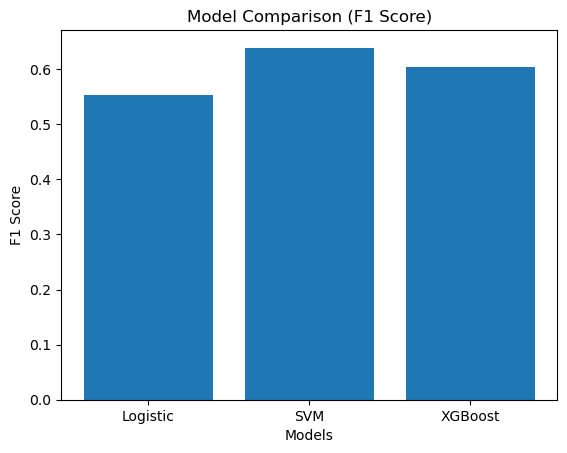

In [136]:

models = ["Logistic", "SVM", "XGBoost"]
scores = [
    f1_score(y_test, y_pred_lr, average="micro"),
    f1_score(y_test, y_pred_svm, average="micro"),
    f1_score(y_test, y_pred_xgb, average="micro"),
]

plt.figure()
plt.bar(models, scores)
plt.title("Model Comparison (F1 Score)")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.show()

In [141]:
# Model Evaluation Summary

# evaluated models using F1 score (micro and macro), 
# as this is a multi-label classification problem.

# Logistic Regression:
# - F1 Micro: ~0.55
# - Performs reasonably well as a baseline
# - Struggles with capturing complex relationships

# XGBoost:
# - F1 Micro: ~0.60
# - Better than Logistic Regression
# - Captures non-linear patterns but not ideal for sparse text data

# Linear SVM:
# - F1 Micro: ~0.64 (Best)
# - Performs best among all models
# - Handles high-dimensional TF-IDF features effectively

In [142]:
#Final Model: Linear SVM

# Reason:
# - Highest F1 score (best performance)
# - Designed for high-dimensional data like text
# - More stable compared to other models

# Conclusion:
# SVM is the most suitable model for this problem

In [138]:
# Top Words/Features Influencing Predictions



feature_names = fb.feature_names()

# Take first classifier (one genre)
coef = model_svm.estimators_[0].coef_[0]

top_idx = coef.argsort()[-20:]

for i in top_idx:
    print(feature_names[i])


# Shows top words/features influencing predictions
# Helps understand what the model is learning

description::impoverished
description::gangster
description::skills
description::cops
description::powers
description::ancient
description::his family
description::true love
description::sequel
description::force
description::terrorist
description::rescue
description::planet
description::intelligence
description::assassin
description::martial
description::soldiers
description::adventure
description::action
description::cia


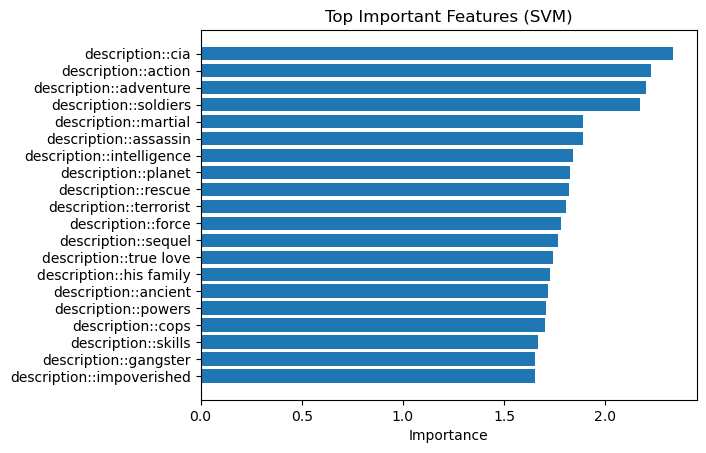

In [140]:

top_features = [feature_names[i] for i in top_idx]
top_values = coef[top_idx]

plt.figure()
plt.barh(top_features, top_values)
plt.title("Top Important Features (SVM)")
plt.xlabel("Importance")
plt.show()

In [143]:
#  Insight

# The plot shows the most important words (features) used by the SVM model 
# to predict genres.

# Observations:
# - Words like "action", "adventure", "soldiers", "assassin" are strongly 
#   associated with action/thriller genres
# - Words like "love", "family" indicate romance or drama genres
# - Words like "terrorist", "cops", "gangster" relate to crime-based genres

# Conclusion:
# The model is learning meaningful patterns from the description text.
# It uses relevant keywords to decide the genre, which makes the model interpretable.